# IP-Adapter Spike v2 — Regular vs Plus-Style Comparison

**Research question this answers:** Does IP-Adapter-Plus (style-emphasised variant) decouple regional folk-art *style* from *content*, where standard IP-Adapter imports both?

**Why this matters:** The earlier smoke test showed regular IP-Adapter at scale 0.6 produces a Madhubani-styled *painting* rather than a Madhubani-styled *snack packet* — the reference's content overwhelms the text prompt. Plus-Style is designed to transfer style without content.

**Grid:**
- 3 prompts × 3 traditions × 2 seeds × 2 variants × 2 scales = **72 conditioned images**
- + 6 baselines (3 prompts × 2 seeds, no reference) = **78 total**
- **Expected runtime on RTX 3060 Laptop (6 GB):** ~110–140 minutes (two model-load swaps)

**Methodological note:** This grid replaces the original (3 scales × 1 variant) plan after the smoke test revealed that regular IP-Adapter imports content alongside style. The comparison is more informative for the dissertation than a single-variant scale sweep. The change and its justification are recorded in `evaluation/methodology_log.md`.

## Cell 1 — Setup and configuration

In [2]:
import os, json, time, gc
from pathlib import Path

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"

import torch
from diffusers import AutoPipelineForText2Image
from diffusers.utils import load_image
from transformers import CLIPVisionModelWithProjection
from PIL import Image
import matplotlib.pyplot as plt

MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"
RESOLUTION = 768                # drop to 640 if Plus OOMs
STEPS = 25
GUIDANCE = 7.5

PROMPTS = {
    "p1": "Front-facing product photograph of an Indian snack packet, professional product photography, white background, sharp focus",
    "p2": "Product packaging design for an Indian potato chips packet, vibrant, professional photo, isolated on white",
    "p3": "Indian savoury snack package, commercial product shot, studio lighting, clean composition",
}
NEGATIVE = "blurry, low quality, watermark, distorted, deformed, jpeg artifacts, multiple products, framed painting, art print, poster"

REFERENCES = {
    "madhubani": "data/processed/style_references/bihar/Craft-2-from-Sunaina-Thakur.png",
    "tanjore":   "data/processed/style_references/tamil_nadu/Navaneeta_Krishna_-_Google_Art_Project.png",
    "kalighat":  "data/processed/style_references/west_bengal/A_Bengali_Lady_Krishna_Killing_the_Demon_Bakasura_6125147052.png",
}

VARIANTS = {
    # name -> (weight filename, optional separate image encoder needed)
    "regular": ("ip-adapter_sdxl.bin",            False),  # uses default bigG encoder
    "plus":    ("ip-adapter-plus_sdxl_vit-h.safetensors", True),  # needs ViT-H encoder
}
SCALES = [0.5, 0.7]
SEEDS = [42, 1337]

OUT_DIR = Path("../outputs/spike/ip_adapter_v2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Sanity check references
print("References:")
for name, path in REFERENCES.items():
    p = Path(path)
    if not p.exists():
        alt = Path("..") / p
        if alt.exists():
            REFERENCES[name] = str(alt)
            print(f"  {name}: {alt}")
        else:
            raise FileNotFoundError(f"Reference for '{name}' not found at {p} or {alt}")
    else:
        print(f"  {name}: {p}")

print(f"\nGPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
print(f"Output: {OUT_DIR.resolve()}")
print(f"Total tasks expected: {2 + 3*3*2*2*2}  (baselines + variants × traditions × prompts × seeds × scales)")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


References:
  madhubani: ..\data\processed\style_references\bihar\Craft-2-from-Sunaina-Thakur.png
  tanjore: ..\data\processed\style_references\tamil_nadu\Navaneeta_Krishna_-_Google_Art_Project.png
  kalighat: ..\data\processed\style_references\west_bengal\A_Bengali_Lady_Krishna_Killing_the_Demon_Bakasura_6125147052.png

GPU: NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB)
Output: C:\Users\Vivek\Documents\dissertation\outputs\spike\ip_adapter_v2
Total tasks expected: 74  (baselines + variants × traditions × prompts × seeds × scales)


## Cell 2 — Helper: build a fresh pipeline with the chosen IP-Adapter variant

Defined as a function so we can rebuild it cleanly between variants. Avoids subtle state-leak bugs from swapping IP-Adapters on a live pipeline.

In [3]:
def build_pipeline(variant_name):
    """Load SDXL + the specified IP-Adapter variant. Returns the pipeline."""
    weight_name, needs_vit_h = VARIANTS[variant_name]
    print(f"Building pipeline with variant: {variant_name}")
    print(f"  Weight file: {weight_name}")
    print(f"  Custom ViT-H encoder: {needs_vit_h}")

    t0 = time.time()

    # Plus variants need ViT-H image encoder; load it explicitly
    extra_kwargs = {}
    if needs_vit_h:
        print("  Loading ViT-H image encoder...")
        image_encoder = CLIPVisionModelWithProjection.from_pretrained(
            "h94/IP-Adapter",
            subfolder="models/image_encoder",
            torch_dtype=torch.float16,
        )
        extra_kwargs["image_encoder"] = image_encoder

    pipe = AutoPipelineForText2Image.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        variant="fp16",
        use_safetensors=True,
        **extra_kwargs,
    )
    pipe.enable_model_cpu_offload()
    pipe.enable_vae_slicing()
    pipe.enable_vae_tiling()

    pipe.load_ip_adapter(
        "h94/IP-Adapter",
        subfolder="sdxl_models",
        weight_name=weight_name,
    )

    # Push image encoder to GPU — cpu_offload doesn't catch it
    if hasattr(pipe, "image_encoder") and pipe.image_encoder is not None:
        pipe.image_encoder.to("cuda")
        print(f"  Image encoder on: {pipe.image_encoder.device}")

    print(f"  Built in {time.time()-t0:.1f}s")
    return pipe


def cleanup_pipeline(pipe):
    """Free the pipeline thoroughly so the next one fits in VRAM."""
    del pipe
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    print("  Pipeline cleaned up.")


print("Helper functions defined.")

Helper functions defined.


## Cell 3 — Quick variant smoke test

Builds Plus pipeline and generates one image to confirm it works in 6 GB VRAM before committing to the full run.

Building pipeline with variant: plus
  Weight file: ip-adapter-plus_sdxl_vit-h.safetensors
  Custom ViT-H encoder: True
  Loading ViT-H image encoder...


Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

...

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2294: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


  Image encoder on: cuda:0
  Built in 6.7s


  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\Vivek\Documents\dissertation\sdxl-env\Lib\site-packages\diffusers\pipelines\stable_diffusion_xl\pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Plus smoke test in 541.4s


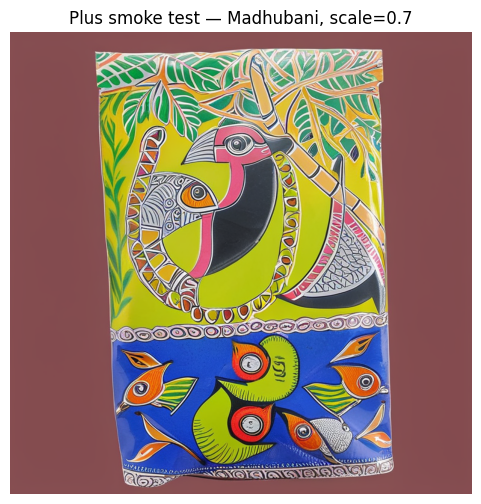


Look at this image carefully:
  - If it looks like a SNACK PACKET with Madhubani styling: Plus is doing what we want
  - If it looks like a painting (like the smoke test of regular IPA): Plus isn't helping
  - Either is a valid finding; proceed to full run either way.


In [4]:
pipe = build_pipeline("plus")
pipe.set_ip_adapter_scale(0.7)
test_ref = load_image(REFERENCES["madhubani"])

g = torch.Generator(device="cuda").manual_seed(42)
t0 = time.time()
img = pipe(
    prompt=PROMPTS["p1"],
    negative_prompt=NEGATIVE,
    ip_adapter_image=test_ref,
    width=RESOLUTION, height=RESOLUTION,
    num_inference_steps=STEPS,
    guidance_scale=GUIDANCE,
    generator=g,
).images[0]
print(f"Plus smoke test in {time.time()-t0:.1f}s")

img.save(OUT_DIR / "_smoke_test_plus.png")
plt.figure(figsize=(6, 6))
plt.imshow(img); plt.axis("off"); plt.title("Plus smoke test — Madhubani, scale=0.7")
plt.show()

print("\nLook at this image carefully:")
print("  - If it looks like a SNACK PACKET with Madhubani styling: Plus is doing what we want")
print("  - If it looks like a painting (like the smoke test of regular IPA): Plus isn't helping")
print("  - Either is a valid finding; proceed to full run either way.")

## Cell 4 — Generation loop: Plus first, then regular

Plus is already loaded. Generate everything Plus first, then swap to regular. Resume-safe.

In [5]:
def filename(variant, tradition, prompt_key, seed, scale):
    if tradition == "baseline":
        return f"baseline_{prompt_key}_s{seed}.png"
    scale_tag = f"{scale:.1f}".replace(".", "")
    return f"{variant}_{tradition}_{prompt_key}_s{seed}_sc{scale_tag}.png"


def generate(pipe, prompt, seed, scale, ref_path_or_none, out_path, variant):
    if out_path.exists():
        return None  # already done

    if scale == 0.0 or ref_path_or_none is None:
        pipe.set_ip_adapter_scale(0.0)
        # diffusers still needs an image arg; pass a Madhubani placeholder, ignored at scale=0
        ref_img = load_image(REFERENCES["madhubani"])
    else:
        pipe.set_ip_adapter_scale(scale)
        ref_img = load_image(ref_path_or_none)

    g = torch.Generator(device="cuda").manual_seed(seed)
    t0 = time.time()
    img = pipe(
        prompt=prompt, negative_prompt=NEGATIVE,
        ip_adapter_image=ref_img,
        width=RESOLUTION, height=RESOLUTION,
        num_inference_steps=STEPS, guidance_scale=GUIDANCE,
        generator=g,
    ).images[0]
    elapsed = time.time() - t0

    img.save(out_path, "PNG")
    config = {
        "prompt": prompt, "negative_prompt": NEGATIVE,
        "seed": seed, "ip_adapter_scale": scale,
        "reference": str(ref_path_or_none) if scale > 0 else "",
        "variant": variant,
        "width": RESOLUTION, "height": RESOLUTION,
        "steps": STEPS, "guidance": GUIDANCE,
        "model": MODEL_ID,
        "elapsed_s": round(elapsed, 1),
    }
    out_path.with_suffix(".json").write_text(json.dumps(config, indent=2))
    return elapsed


def build_task_list(variant):
    """All conditioned tasks for one variant."""
    tasks = []
    for tradition, ref_path in REFERENCES.items():
        for pk, prompt in PROMPTS.items():
            for seed in SEEDS:
                for scale in SCALES:
                    out = OUT_DIR / filename(variant, tradition, pk, seed, scale)
                    tasks.append({"prompt": prompt, "seed": seed, "scale": scale,
                                  "ref": ref_path, "out": out, "variant": variant,
                                  "tag": f"{variant} {tradition} {pk} s{seed} sc={scale}"})
    return tasks


def run_tasks(pipe, tasks):
    new = 0
    for i, t in enumerate(tasks, 1):
        if t["out"].exists():
            print(f"[{i:>3}/{len(tasks)}] SKIP {t['tag']}")
            continue
        print(f"[{i:>3}/{len(tasks)}] {t['tag']} ...", end=" ", flush=True)
        elapsed = generate(pipe, t["prompt"], t["seed"], t["scale"], t["ref"], t["out"], t["variant"])
        print(f"{elapsed:.1f}s")
        new += 1
    return new


# ----- Phase 1: Plus (pipe is already loaded from Cell 3) -----
plus_tasks = build_task_list("plus")
print(f"\n=== Phase 1: Plus variant ({len(plus_tasks)} tasks) ===")
phase_start = time.time()
new_plus = run_tasks(pipe, plus_tasks)
print(f"\nPhase 1 done. {new_plus} new images in {(time.time()-phase_start)/60:.1f} min.")

# Free VRAM before loading regular variant
print("\nSwapping to regular variant...")
cleanup_pipeline(pipe)
pipe = build_pipeline("regular")

# ----- Phase 2: regular -----
regular_tasks = build_task_list("regular")
print(f"\n=== Phase 2: Regular variant ({len(regular_tasks)} tasks) ===")
phase_start = time.time()
new_reg = run_tasks(pipe, regular_tasks)
print(f"\nPhase 2 done. {new_reg} new images in {(time.time()-phase_start)/60:.1f} min.")

# ----- Baselines (use whichever pipeline is loaded — scale=0 means IPA off) -----
print("\n=== Phase 3: Baselines (scale=0.0, no reference) ===")
for pk, prompt in PROMPTS.items():
    for seed in SEEDS:
        out = OUT_DIR / filename("baseline", "baseline", pk, seed, 0.0)
        if out.exists():
            print(f"  SKIP baseline_{pk}_s{seed}")
            continue
        t0 = time.time()
        elapsed = generate(pipe, prompt, seed, 0.0, None, out, "baseline")
        print(f"  baseline_{pk}_s{seed}: {elapsed:.1f}s")

print(f"\nALL DONE. Outputs in {OUT_DIR.resolve()}")


=== Phase 1: Plus variant (36 tasks) ===
[  1/36] SKIP plus madhubani p1 s42 sc=0.5
[  2/36] SKIP plus madhubani p1 s42 sc=0.7
[  3/36] SKIP plus madhubani p1 s1337 sc=0.5
[  4/36] SKIP plus madhubani p1 s1337 sc=0.7
[  5/36] SKIP plus madhubani p2 s42 sc=0.5
[  6/36] SKIP plus madhubani p2 s42 sc=0.7
[  7/36] SKIP plus madhubani p2 s1337 sc=0.5
[  8/36] SKIP plus madhubani p2 s1337 sc=0.7
[  9/36] SKIP plus madhubani p3 s42 sc=0.5
[ 10/36] SKIP plus madhubani p3 s42 sc=0.7
[ 11/36] SKIP plus madhubani p3 s1337 sc=0.5
[ 12/36] SKIP plus madhubani p3 s1337 sc=0.7
[ 13/36] SKIP plus tanjore p1 s42 sc=0.5
[ 14/36] SKIP plus tanjore p1 s42 sc=0.7
[ 15/36] SKIP plus tanjore p1 s1337 sc=0.5
[ 16/36] SKIP plus tanjore p1 s1337 sc=0.7
[ 17/36] SKIP plus tanjore p2 s42 sc=0.5
[ 18/36] SKIP plus tanjore p2 s42 sc=0.7
[ 19/36] SKIP plus tanjore p2 s1337 sc=0.5
[ 20/36] SKIP plus tanjore p2 s1337 sc=0.7
[ 21/36] SKIP plus tanjore p3 s42 sc=0.5
[ 22/36] SKIP plus tanjore p3 s42 sc=0.7
[ 23/36] SKI

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/776 [00:00<?, ?it/s]

...

  baseline_p2_s1337: 1032.9s


  0%|          | 0/25 [00:02<?, ?it/s]

  baseline_p3_s42: 730.4s


  0%|          | 0/25 [00:02<?, ?it/s]

  baseline_p3_s1337: 643.9s

ALL DONE. Outputs in C:\Users\Vivek\Documents\dissertation\outputs\spike\ip_adapter_v2


## Cell 5 — Build comparison grid

Rows: tradition + scale + seed. Two columns per prompt: regular | plus side-by-side. Plus baselines block at the top.

Comparison grid saved: C:\Users\Vivek\Documents\dissertation\outputs\spike\ip_adapter_v2_comparison_grid.png
  Size: (880, 5750)


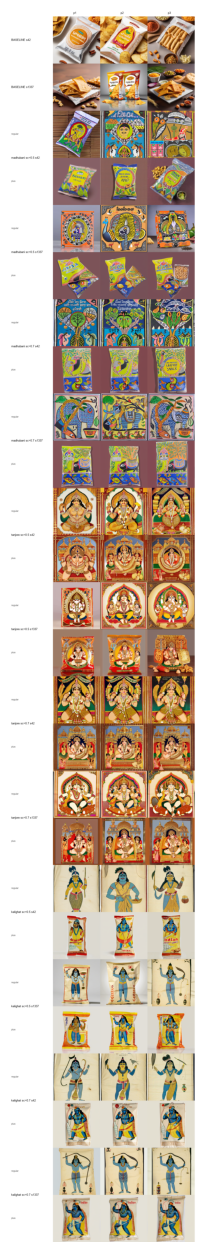

In [6]:
from PIL import ImageDraw, ImageFont

thumb = 220
label_w = 200
n_prompts = len(PROMPTS)
cols = n_prompts * 2 + 1   # for each prompt: regular | plus, with a separator

blocks = []

# Baseline block
for seed in SEEDS:
    row = []
    for pk in PROMPTS:
        p = OUT_DIR / filename("baseline", "baseline", pk, seed, 0.0)
        row.append(Image.open(p).resize((thumb, thumb)) if p.exists() else None)
    blocks.append((f"BASELINE s{seed}", row, "baseline"))

# Variant comparison blocks: same row shows regular and plus side-by-side per prompt
for tradition in REFERENCES:
    for scale in SCALES:
        for seed in SEEDS:
            row_reg = []
            row_plus = []
            for pk in PROMPTS:
                r = OUT_DIR / filename("regular", tradition, pk, seed, scale)
                p = OUT_DIR / filename("plus", tradition, pk, seed, scale)
                row_reg.append(Image.open(r).resize((thumb, thumb)) if r.exists() else None)
                row_plus.append(Image.open(p).resize((thumb, thumb)) if p.exists() else None)
            blocks.append((f"{tradition} sc={scale} s{seed}", (row_reg, row_plus), "compare"))

# Render canvas
header_h = 30
n_rows = sum(1 if b[2] == "baseline" else 2 for b in blocks)  # compare rows are 2 high
canvas_h = header_h + n_rows * thumb
canvas_w = label_w + n_prompts * thumb + 20  # +20 for between-prompt gaps
canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("arial.ttf", 13)
    font_small = ImageFont.truetype("arial.ttf", 11)
except Exception:
    font = font_small = ImageFont.load_default()

# Column headers
for j, pk in enumerate(PROMPTS):
    draw.text((label_w + j * thumb + thumb // 2 - 15, 6), pk, fill="black", font=font)

y = header_h
for lab, payload, kind in blocks:
    if kind == "baseline":
        draw.text((6, y + thumb // 2 - 8), lab, fill="black", font=font)
        for j, im in enumerate(payload):
            if im is not None:
                canvas.paste(im, (label_w + j * thumb, y))
        y += thumb
    else:
        row_reg, row_plus = payload
        draw.text((6, y + thumb - 8), lab, fill="black", font=font)
        draw.text((6, y + thumb // 2 - 8), "regular", fill="#555", font=font_small)
        draw.text((6, y + thumb + thumb // 2 - 8), "plus", fill="#555", font=font_small)
        for j, im in enumerate(row_reg):
            if im is not None:
                canvas.paste(im, (label_w + j * thumb, y))
        for j, im in enumerate(row_plus):
            if im is not None:
                canvas.paste(im, (label_w + j * thumb, y + thumb))
        y += thumb * 2

grid_path = OUT_DIR.parent / "ip_adapter_v2_comparison_grid.png"
canvas.save(grid_path)
print(f"Comparison grid saved: {grid_path.resolve()}")
print(f"  Size: {canvas.size}")

plt.figure(figsize=(14, 16))
plt.imshow(canvas); plt.axis("off")
plt.show()

## Cell 6 — Failure-log CSV scaffold (rubric scoring)

Pre-committed rubric: 4 axes, 0–3 scale, two sessions ≥48h apart.

In [7]:
import pandas as pd

rows = []
for p in sorted(OUT_DIR.glob("*.png")):
    if p.name.startswith("_"):  # skip smoke tests
        continue
    stem = p.stem
    parts = stem.split("_")
    if stem.startswith("baseline_"):
        variant, tradition = "baseline", "baseline"
        scale_str = "0.0"
    else:
        variant = parts[0]               # regular | plus
        tradition = parts[1]
        scale_raw = parts[-1].replace("sc", "")
        scale_str = f"{scale_raw[0]}.{scale_raw[1:]}" if len(scale_raw) > 1 else scale_raw

    rows.append({
        "filename": p.name, "variant": variant, "tradition": tradition, "ip_scale": scale_str,
        "session1_text_legibility": "",
        "session1_regional_appropriateness": "",
        "session1_packaging_plausibility": "",
        "session1_visual_quality": "",
        "session1_date": "",
        "session2_text_legibility": "",
        "session2_regional_appropriateness": "",
        "session2_packaging_plausibility": "",
        "session2_visual_quality": "",
        "session2_date": "",
        "failure_mode": "",
        "notes": "",
    })

df = pd.DataFrame(rows)
log_path = Path("../evaluation/spike_v2_scores.csv")
log_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(log_path, index=False)
print(f"Score scaffold: {log_path.resolve()}  ({len(df)} rows)")

Score scaffold: C:\Users\Vivek\Documents\dissertation\evaluation\spike_v2_scores.csv  (78 rows)
